# Spyro 3D mesh generation with Gmsh tutorial

Spyro have a meshing framework based on Gmsh to simplify the generation of seismic meshes.  With the framework it is easy to generate
different kinds of meshes according to the seismic problem in question. In this tutorial a 3D mesh will be generated using a example 
velocity model, using most of the features available in the framework.

Model:

- physical domain: `5000 × 5000 × 3000 m` (`x × y × z`);
- velocity model: `vs_example_3D.bin`;
- binary grid: `(nz, nx, ny) = (101, 101, 101)`;
- spacing: `(dz, dx, dy) = (30, 50, 50) m`;
- binary storage: big-endian `float32`, Fortran order `(z, x, y)`;
- output mesh: `example_mesh_3D.msh`;
- output figure: `example_mesh_3D.png`.


In [1]:
from pathlib import Path

import gmsh
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from spyro.meshing import AutomaticMesh, MeshingParameters

try:
    from spyro.meshing.meshing_gmsh3D import (
        build_gmsh_geometry_and_groups3D,
    )
except ImportError as exc:
    raise ImportError(
        "This notebook requires the Spyro and spyro.meshing.meshing_gmsh3D."
    ) from exc



firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Model and meshing parameters

3D velocity models are usually stored in .BIN files, and to correctly mesh the model we need to introduce the geometry specifications. For the example model we will have depth z = 3000m and lenght x/y = 5000m. We can generate meshes with or without padding area (with rectangular or hyperelliptical geometry) so we will use the padding size = 1000m.  The .BIN files have the velocity model described by the number of points in each axis (nz, nx, ny) separated by the distances (dz, dx, dy). We input these values below:

The model is stored in `(z, x, y)` order with Fortran ordering.


In [2]:
domain_x = 5000.0 # Domain lenght x
domain_y = 5000.0 # Domain lenght y
domain_z = 3000.0 # Domain depth z

nz, nx, ny = 101, 101, 101 # Number of grid points in z,x,y
dz, dx, dy = 30.0, 50.0, 50.0 # Distance between grid points

padding_x = 1000.0 # Padding size
padding_y = 1000.0
padding_z = 1000.0

velocity_candidates = [
    Path("velocity_models/vs_example_3D.bin")
]

velocity_file = next(
    (path for path in velocity_candidates if path.is_file()),
    velocity_candidates[0],
)

mesh_file = Path("example_mesh_3D.msh")
figure_file = Path("example_mesh_3D.png")

if not velocity_file.is_file():
    raise FileNotFoundError(
        "Velocity model not found."
    )

## Inspect the 3D velocity model

Here we load the .BIN file using the package segyio, the velocity model is ploted.


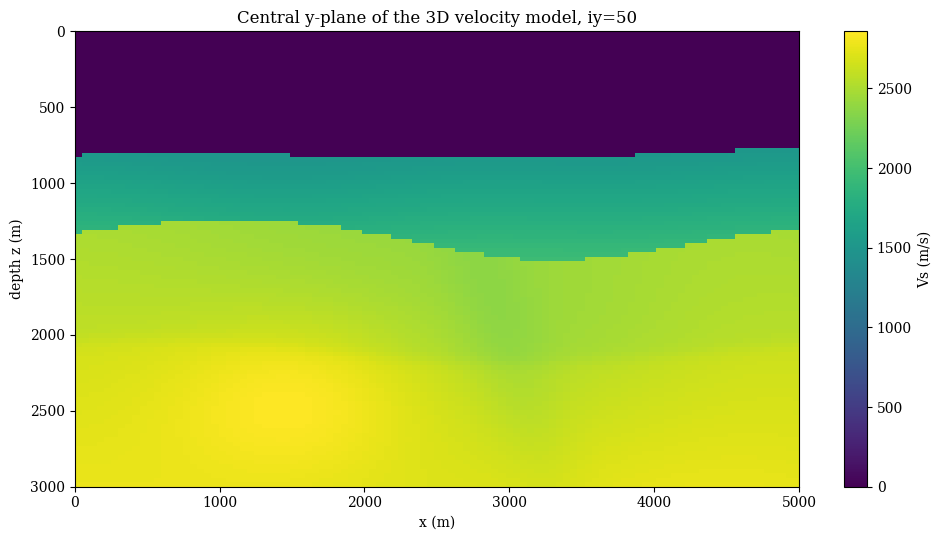

Cube shape:              (101, 101, 101)
Positive Vs minimum:     1501.000 m/s
Positive Vs maximum:     2974.564 m/s
Zero-valued samples:     281,195


In [3]:
vs_cube = np.fromfile(
    velocity_file,
    dtype=">f4",
).reshape(
    (nz, nx, ny),
    order="F",
)

positive = vs_cube[vs_cube > 0.0]

if positive.size == 0:
    raise ValueError("The velocity model contains no positive velocities.")

iy = ny // 2
vs_plane = vs_cube[:, :, iy]

x_model = np.arange(nx) * dx
z_model = np.arange(nz) * dz

fig, ax = plt.subplots(figsize=(10, 5.5))

image = ax.imshow(
    vs_plane,
    extent=[
        x_model.min(),
        x_model.max(),
        z_model.max(),
        z_model.min(),
    ],
    aspect="auto",
)

fig.colorbar(image, ax=ax, label="Vs (m/s)")

ax.set_xlabel("x (m)")
ax.set_ylabel("depth z (m)")
ax.set_title(
    f"Central y-plane of the 3D velocity model, iy={iy}"
)

plt.tight_layout()
plt.show()

print(f"Cube shape:              {vs_cube.shape}")
print(f"Positive Vs minimum:     {positive.min():.3f} m/s")
print(f"Positive Vs maximum:     {positive.max():.3f} m/s")
print(f"Zero-valued samples:     {np.count_nonzero(vs_cube == 0.0):,}")


## Spyro 3D Gmsh mesh parameters

Three examples are provided. Change `mesh_example` to select one.

### Example 1
Unstructured tetrahedral mesh, rectangular padding, no explicit water
interface, with velocity-based sizing extended into the padding.

### Example 2
Unstructured tetrahedral mesh, hyperelliptical padding, explicit water
interface, and constant padding mesh size.

### Example 3
Structured hexahedral mesh, no padding, explicit water interface, with
Winslow smoothing.


In [4]:
mesh_example = 1
if mesh_example == 1:
    # Unstructured tetrahedral mesh with rectangular padding,
    # no water interface and extended mesh size into the padding
    frequency = 3.0                  # Velocity-model/source frequency in Hz
    wl = 2.0                         # Number of elements per wavelength
    grade = 0.05                     # Controls smooth element-size transition; 0.9 = high smoothing, 0.05 = small smoothing
    hmin_segy = 0.0                  # Minimum element-size limit for velocity-model-based sizing; leave 0.0 for no change
    padding_type = "rectangular"     # Use rectangular absorbing-layer padding
    hyper_n = 4                      # Not used here; only used for hyperelliptical padding
    water_interface = False          # Do not delimit the water/subsurface interface
    structured_mesh = False          # Generate an unstructured tetrahedral mesh
    min_element_size = 150.0         # Not used here; structured-mesh size parameter
    extend_segy = True               # Extend the velocity-model-derived mesh size into the padding
    h_padding = 500.0                # Not used here; padding size comes from extended velocity-model sizing
    apply_winslow = False            # Not used here; do not apply Winslow mesh smoothing

elif mesh_example == 2:
    # Unstructured tetrahedral mesh with hyperelliptical padding,
    # delimited water interface and constant padding mesh size
    frequency = 3.0                  # Velocity-model/source frequency in Hz
    wl = 2.0                         # Number of elements per wavelength
    grade = 0.05                     # Controls smooth element-size transition; 0.9 = high smoothing, 0.05 = small smoothing
    hmin_segy = 0.0                  # Minimum element-size limit for velocity-model-based sizing; leave 0.0 for no change
    padding_type = "hyperelliptical" # Use hyperelliptical absorbing-layer padding
    hyper_n = 4                      # Hyperellipse exponent controlling the padding shape
    water_interface = True           # Delimit the water/subsurface interface using water_search_value
    structured_mesh = False          # Generate an unstructured tetrahedral mesh
    min_element_size = 150.0         # Not used here; structured-mesh size parameter
    extend_segy = False              # Do not extend model sizing; use h_padding inside the padding
    h_padding = 500.0                # Constant element size used inside the padding
    apply_winslow = False            # Not used here; do not apply Winslow mesh smoothing

elif mesh_example == 3:
    # Structured hexahedral mesh with no padding,
    # no delimited water interface and Winslow smoothing
    frequency = 3.0                  # Not used here; structured mesh uses min_element_size
    wl = 2.0                         # Not used here; structured mesh uses min_element_size
    grade = 0.1                      # Controls smooth element-size transition;
    hmin_segy = 0.0                  # Not used here; no unstructured velocity-model mesh sizing
    padding_type = None              # Disable padding
    hyper_n = 4                      # Not used here; there is no hyperelliptical padding
    water_interface = False          # Do not delimit the water/subsurface interface
    structured_mesh = True           # Generate a structured hexahedral mesh
    min_element_size = 100.0         # Element size used to construct the structured mesh
    extend_segy = False              # Not used here; there is no padding to extend sizing into
    h_padding = 500.0                # Not used here; there is no padding
    apply_winslow = True             # Apply Winslow smoothing to conform the structured mesh
else:
    raise ValueError(
        f"Invalid mesh_example={mesh_example}. "
        "Choose mesh_example = 1, 2, or 3."
    )

mesh_dictionary = {
    "mesh_type": "gmsh_mesh",
    "dimension": 3,
    "length_z": domain_z,
    "length_x": domain_x,
    "length_y": domain_y,
    "output_filename": str(mesh_file),
    "cells_per_wavelength": wl,
    "source_frequency": frequency,
    "frequency": frequency,
    "grade": grade,
    "hmin_segy": hmin_segy,
    "segy_velocity_model": str(velocity_file),
    "segy_nz": nz,
    "segy_nx": nx,
    "segy_ny": ny,
    "segy_dz": dz,
    "segy_dx": dx,
    "segy_dy": dy,
    "segy_byte_order": "big",
    "segy_axes_order": (0, 1, 2),
    "segy_axes_order_sort": "F",
    "segy_dtype": "float32",
    "padding_type": padding_type,
    "padding_x": padding_x,
    "padding_y": padding_y,
    "padding_z": padding_z,
    "hyper_n": hyper_n,
    "water_interface": water_interface,
    "water_search_value": 0.0,
    "vp_water": 1000.0,
    "structured_mesh": structured_mesh,
    "min_element_size": min_element_size,
    "extend_segy": extend_segy,
    "h_padding": h_padding,
    "apply_winslow": apply_winslow,
    "winslow_implementation": "numba",
    "winslow_iterations": 1000,
    "winslow_omega": 0.5,
    "gmsh_parallel": False,
}

mesh_parameters = MeshingParameters(
    input_mesh_dictionary=mesh_dictionary,
    dimension=3,
    source_frequency=frequency,
    comm=None,
    quadrilateral=False,
    method="mass_lumped_triangle",
    degree=3,
    abc_pad_length=None,
    negative_z=True,
)

# Keep all PR #359 3D parameters available on the parameter object.
for name, value in mesh_dictionary.items():
    try:
        setattr(mesh_parameters, name, value)
    except (AttributeError, TypeError, ValueError):
        pass

print("3D meshing parameters created.")
print(f"mesh_example:      {mesh_example}")
print(f"padding_type:      {padding_type}")
print(f"water_interface:   {water_interface}")
print(f"structured_mesh:   {structured_mesh}")
print(f"apply_winslow:     {apply_winslow}")


3D meshing parameters created.
mesh_example:      1
padding_type:      rectangular
water_interface:   False
structured_mesh:   False
apply_winslow:     False


/home/juninhoras/firedrakes/spyro/spyro/meshing/meshing_parameters.py:1197: UserWarning: Passing SEGY directly to the mesher is deprecated. Please use grid point velocity inputs.
  warn("Passing SEGY directly to the mesher is deprecated. Please use grid point velocity inputs.")


## Generate the 3D mesh

Using create_gmsh_3D_mesh() we will generate the .msh mesh file.


In [5]:
automatic_mesh = AutomaticMesh(
    mesh_parameters=mesh_parameters
)

if not hasattr(
    automatic_mesh,
    "create_gmsh_3D_mesh",
):
    raise AttributeError(
        "This Spyro version does not use"
        "AutomaticMesh.create_gmsh_3D_mesh(). "
    )

automatic_mesh.create_gmsh_3D_mesh()

if not mesh_file.is_file():
    raise RuntimeError(
        f"Mesh generation finished but {mesh_file} was not created."
    )

print("3D mesh created successfully.")


Generating 3D Gmsh mesh...
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Generating undelimited water+subsurface domain with rectangular padding...
Info    : Meshing 1D...                                                                                                                 
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 20%] Meshing curve 16 (Line)
Info    : [ 20%] Meshing c

##  Plot of the generated 3D mesh

The generated `.msh` is read directly with Gmsh, the obtained nodes and connections are used to plot the mesh using Matplotlib

The code writes the mesh in Spyro coordinate order `(z, x, y)`. For plotting,
the coordinates are reordered to `(x, y, z)`.


Info    : Reading 'example_mesh_3D.msh'...
Info    : 245 entities
Info    : 10896 nodes
Info    : 50756 elements
Info    : Done reading 'example_mesh_3D.msh'


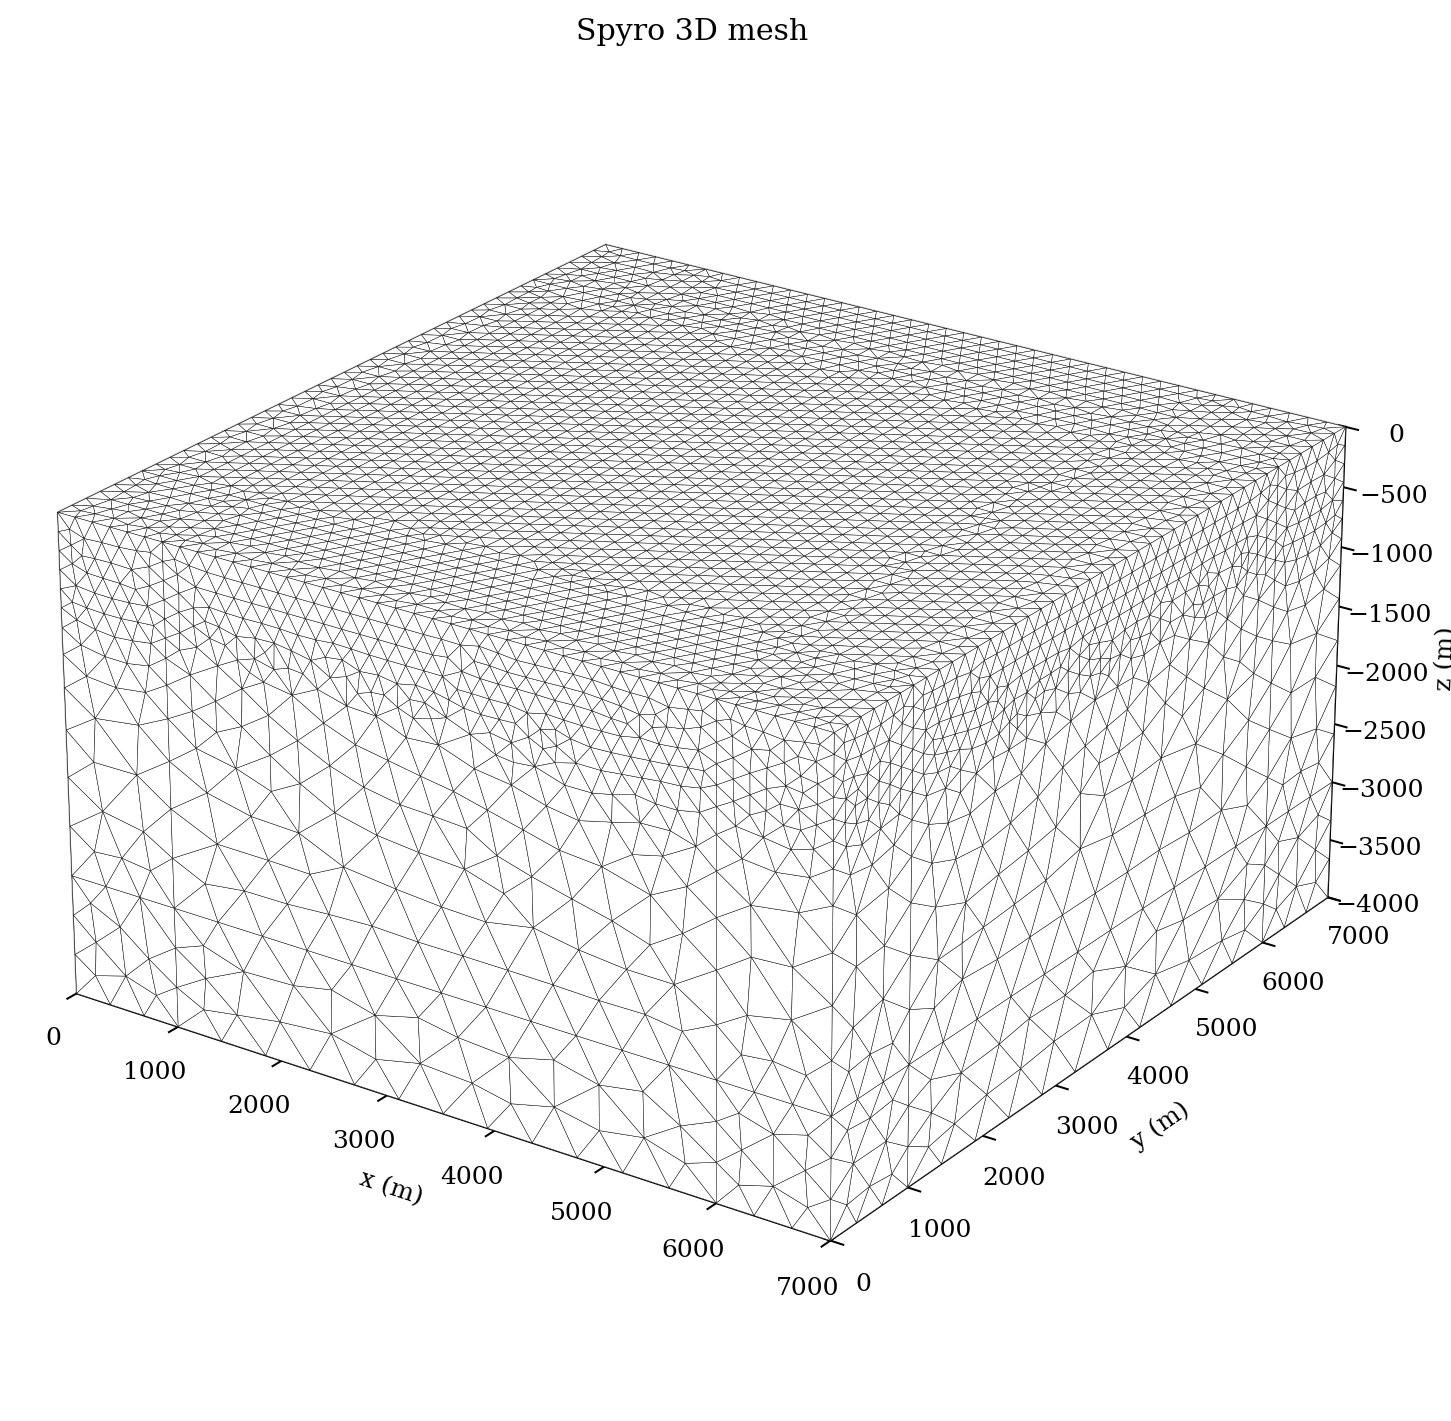

Nodes:              10,896
Tetrahedra:         50,756
Hexahedra:          0
Exterior triangles: 8,750
Exterior quads:     0


In [6]:
def boundary_faces_from_cells(cells, local_faces):
    faces = np.concatenate([cells[:, face] for face in local_faces], axis=0)
    keys = np.sort(faces, axis=1)
    _, first_index, counts = np.unique(keys, axis=0, return_index=True, return_counts=True)
    return faces[first_index[counts == 1]]


def read_3d_boundary(msh_path):
    gmsh.initialize()

    try:
        gmsh.open(str(msh_path))

        node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
        node_tags = np.asarray(node_tags, dtype=np.int64)
        coordinates = np.asarray(node_coords, dtype=float).reshape(-1, 3)
        tag_to_index = {int(tag): i for i, tag in enumerate(node_tags)}

        triangle_faces, quad_faces = [], []
        n_tetra, n_hexa = 0, 0

        element_types, _, element_nodes = gmsh.model.mesh.getElements(dim=3)

        for element_type, flat_nodes in zip(element_types, element_nodes):
            name, dim, order, nodes_per_element, _, num_primary_nodes = gmsh.model.mesh.getElementProperties(element_type)

            if dim != 3:
                continue

            connectivity = np.asarray(flat_nodes, dtype=np.int64).reshape(-1, nodes_per_element)
            lower_name = name.lower()

            if "tetrahedron" in lower_name:
                corners = connectivity[:, :4]
                indexed = np.fromiter(
                    (tag_to_index[int(tag)] for tag in corners.ravel()),
                    dtype=np.int64,
                    count=corners.size,
                ).reshape(-1, 4)

                local_faces = [[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]]
                triangle_faces.append(boundary_faces_from_cells(indexed, local_faces))
                n_tetra += len(indexed)

            elif "hexahedron" in lower_name:
                corners = connectivity[:, :8]
                indexed = np.fromiter(
                    (tag_to_index[int(tag)] for tag in corners.ravel()),
                    dtype=np.int64,
                    count=corners.size,
                ).reshape(-1, 8)

                local_faces = [
                    [0, 1, 2, 3],
                    [4, 5, 6, 7],
                    [0, 1, 5, 4],
                    [1, 2, 6, 5],
                    [2, 3, 7, 6],
                    [3, 0, 4, 7],
                ]

                quad_faces.append(boundary_faces_from_cells(indexed, local_faces))
                n_hexa += len(indexed)

        triangles = np.vstack(triangle_faces) if triangle_faces else np.empty((0, 3), dtype=np.int64)
        quads = np.vstack(quad_faces) if quad_faces else np.empty((0, 4), dtype=np.int64)

        if n_tetra == 0 and n_hexa == 0:
            raise RuntimeError("No tetrahedral or hexahedral volume elements were found in the .msh file.")

        return coordinates, triangles, quads, n_tetra, n_hexa

    finally:
        gmsh.finalize()


coordinates, triangles, quads, n_tetra, n_hexa = read_3d_boundary(mesh_file)

# Spyro order: (z, x, y) -> plot order: (x, y, z)
xyz = coordinates[:, [1, 2, 0]]

fig = plt.figure(figsize=(12, 8), dpi=180)
ax = fig.add_subplot(111, projection="3d")

if len(triangles):
    triangle_surface = Poly3DCollection(
        xyz[triangles],
        facecolors="white",
        edgecolors="black",
        linewidths=0.18,
        alpha=1.0,
    )
    ax.add_collection3d(triangle_surface)

if len(quads):
    quad_surface = Poly3DCollection(
        xyz[quads],
        facecolors="white",
        edgecolors="black",
        linewidths=0.18,
        alpha=1.0,
    )
    ax.add_collection3d(quad_surface)

mins = xyz.min(axis=0)
maxs = xyz.max(axis=0)
span = np.maximum(maxs - mins, 1.0)

ax.set_xlim(mins[0], maxs[0])
ax.set_ylim(mins[1], maxs[1])
ax.set_zlim(mins[2], maxs[2])
ax.set_box_aspect(span)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Spyro 3D mesh")
ax.view_init(elev=24, azim=-55)

plt.tight_layout()
plt.savefig(figure_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Nodes:              {len(coordinates):,}")
print(f"Tetrahedra:         {n_tetra:,}")
print(f"Hexahedra:          {n_hexa:,}")
print(f"Exterior triangles: {len(triangles):,}")
print(f"Exterior quads:     {len(quads):,}")

## Outputs

After running the notebook, the generated files are:

```text
example_mesh_3D.msh
example_mesh_3D.png
```
